# Gradient Descent from Scratch

This notebook demonstrates how to implement a basic gradient descent algorithm from scratch to perform linear regression. We start by loading the dataset, then we define a loss function (Mean Squared Error). The `gradient_descent` function updates the slope (`m`) and intercept (`b`) iteratively by calculating the gradient of the loss function. Finally, we train the model and visualize the resulting regression line.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1️⃣ Load the Dataset

We load the dataset using **pandas**.

The dataset contains:

- hours_studied
- exam_score

In [6]:
data = pd.read_csv('data.csv')

data.head()

,student_id,name,course,hours_studied,attendance_percent,exam_score
0,1,Sara,Math,9,75,64
1,2,Marta,Math,18,65,87
2,3,Ruth,Math,1,65,63
3,4,Dawit,Linear Algebra,20,61,85
4,5,Dawit,Linear Algebra,14,74,78


## 2️⃣ Prepare Input (X) and Output (Y)

In machine learning:

- **X** = input feature (hours studied)
- **y** = target variable (exam score)

In [7]:
x = data['hours_studied'].values
y = data['exam_score'].values

## 3️⃣ Visualize the Dataset

We plot the data to see the relationship between:

- Hours studied
- Exam score

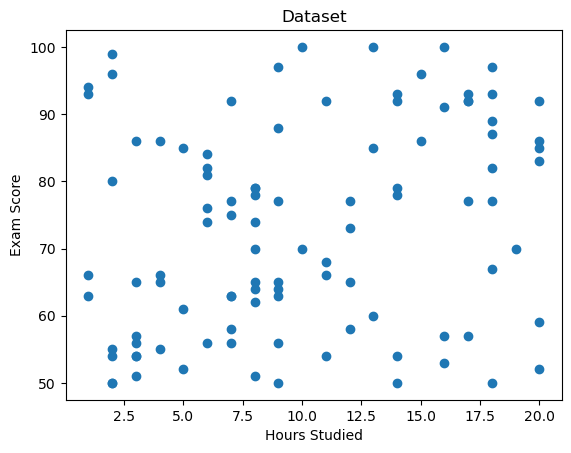

In [8]:
plt.scatter(x, y)

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.title("Dataset")

plt.show()

## 4️⃣ Loss Function

The **loss function** measures how wrong our predictions are.

We use **Mean Squared Error (MSE)**.

Formula:

Loss = (1/N) * Σ (y_pred − y)²

In [9]:
def loss_function(m, b, x, y):

    total_loss = 0
    N = len(x)

    for i in range(N):
        y_pred = m * x[i] + b
        total_loss += (y_pred - y[i]) ** 2

    return total_loss / N

## 5️⃣ Gradient Descent

Gradient Descent updates the parameters:

- **m** → slope
- **b** → intercept

to minimize the loss.

In [10]:
def gradient_descent(m, b, x, y, learning_rate):

    m_gradient = 0
    b_gradient = 0
    N = len(x)

    for i in range(N):

        y_pred = m * x[i] + b

        m_gradient += -(2/N) * x[i] * (y[i] - y_pred)
        b_gradient += -(2/N) * (y[i] - y_pred)

    step_size_slope = learning_rate * m_gradient
    step_size_intercept = learning_rate * b_gradient

    m -= step_size_slope
    b -= step_size_intercept

    return m, b

## 6️⃣ Train the Model

We start with:

m = 0  
b = 0  

Then we update them using **gradient descent** for many iterations.

In [ ]:
m = 0
b = 0

learning_rate = 0.0001
epochs = 1000

for i in range(epochs):

    m, b = gradient_descent(m, b, x, y, learning_rate)

    if i % 100 == 0:
        loss = loss_function(m, b, x, y)
        print(f"Epoch {i}, Loss: {loss}")
print(f"Final parameters: m = {m}, b = {b}")
        

Epoch 0, Loss: 5326.105929717317
Final parameters: m = 0.14959400000000003, b = 0.014578000000000004
Epoch 100, Loss: 1314.2890489990107
Final parameters: m = 5.2359777817574615, b = 0.7269879477151479
Epoch 200, Loss: 1285.4818347418397
Final parameters: m = 5.555799439612996, b = 1.0783000789179422
Epoch 300, Loss: 1274.8600837737563
Final parameters: m = 5.554586986308568, b = 1.4037771584157477
Epoch 400, Loss: 1264.4248072246262
Final parameters: m = 5.531857834423773, b = 1.7260150326710262
Epoch 500, Loss: 1254.093270907179
Final parameters: m = 5.5077914439727005, b = 2.046543540350593
Epoch 600, Loss: 1243.8640799964744
Final parameters: m = 5.483746850108274, b = 2.365473158404317
Epoch 700, Loss: 1233.7362189967575
Final parameters: m = 5.459815062401144, b = 2.6828186973556796
Epoch 800, Loss: 1223.7086841309392
Final parameters: m = 5.436001659806773, b = 2.998588485611323
Epoch 900, Loss: 1213.780481572832
Final parameters: m = 5.4123064681277535, b = 3.3127903784461137


## 7️⃣ Final Model Parameters

In [12]:
print("Final parameters:")
print("m =", m)
print("b =", b)

Final parameters:
m = 5.38896412321231
b = 3.622313442261826


## 8️⃣ Plot the Regression Line

Now we visualize the **best fit line** learned by the model.

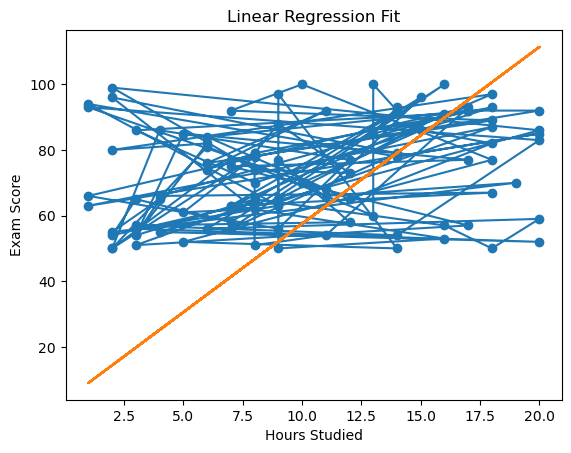

In [13]:
y_pred = m * x + b

plt.scatter(x, y)

plt.plot(x, y)
plt.plot(x, y_pred)

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.title("Linear Regression Fit")

plt.show()